### ASEN-6062
### Celestial Mechanics
#### Hwk 2
#### Nicole James

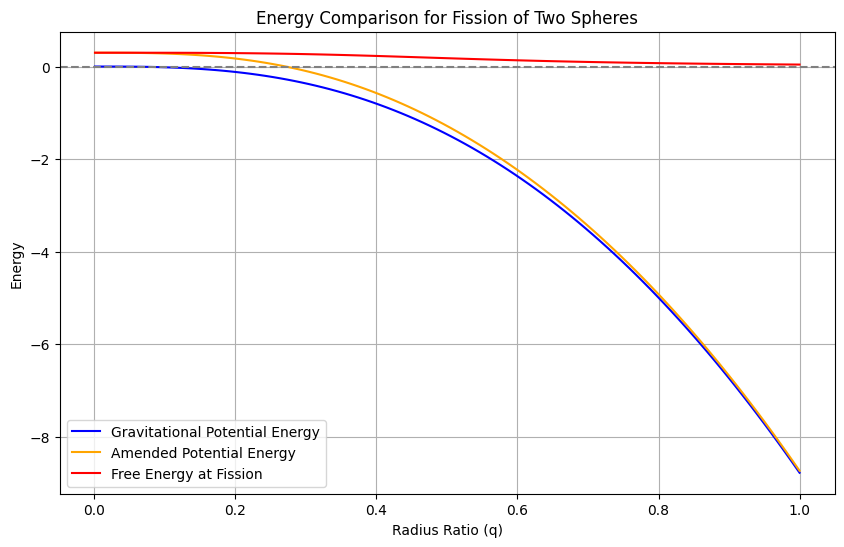

In [3]:
# Build an app to study spin rate for fission of 2 spheres
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 1  # Gravitational constant normalized
# Fixed angular momentum (normalized units). Change as needed.
H = 1.0

q_vals = np.linspace(0.001, 1, 100)  # Radius ratio values for evaluation
U_amended = []
U_gravity = []
free_energy = []

for q in q_vals:
    R2 = 1.0
    R1 = R2 * q  # create radius ratio
    M1 = (4/3) * np.pi * R1**3  # Mass of sphere 1
    M2 = (4/3) * np.pi * R2**3  # Mass of sphere 2
    mu = M1 * M2 / (M1 + M2)  # Reduced mass
    d = R1 + R2  # Distance between centers

    # Inertias (assume (2/5) * M * R^2 for each sphere)
    I1 = (2/5) * M1 * R1**2
    I2 = (2/5) * M2 * R2**2
    Iorb = mu * d**2  # Orbital inertia
    I_total = I1 + I2 + Iorb  # Total inertia of the system

    # mutual gravitational potential energy
    U_grav = -G * M1 * M2 / d
    U_gravity.append(U_grav)

    # amended potential energy for fixed angular momentum H: U_amend = U_grav + H^2/(2*I_total)
    U_amend = U_grav + H**2 / (2 * I_total)
    U_amended.append(U_amend)

    # free energy (amended minus gravitational) appended for every q so arrays match for plotting
    free_energy.append(U_amend - U_grav)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(q_vals, U_gravity, label='Gravitational Potential Energy', color='blue')
plt.plot(q_vals, U_amended, label='Amended Potential Energy', color='orange')
plt.plot(q_vals, free_energy, label='Free Energy at Fission', color='red')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Radius Ratio (q)')
plt.ylabel('Energy')
plt.title('Energy Comparison for Fission of Two Spheres')
plt.legend()
plt.grid()
plt.show()

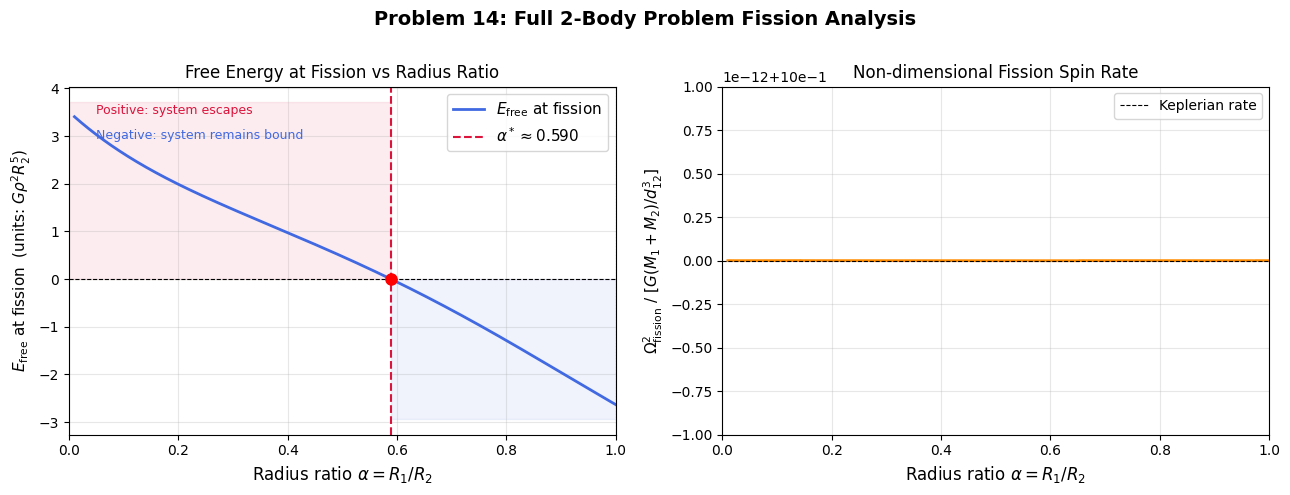

Problem 14: Fission Analysis Summary
  Zero crossing (E_free = 0) at alpha = R1/R2 = 0.5897
  For alpha < 0.5897: E_free > 0  →  system ESCAPES
  For alpha > 0.5897: E_free < 0  →  system BOUND

     alpha     I_S_bar          E_free     omega2_nd
  --------  ----------  --------------  ------------
     0.010    39.60400        3.405983      1.000000
     0.109     3.31003        2.565257      1.000000
     0.208     1.60453        1.942935      1.000000
     0.307     1.02459        1.425937      1.000000
     0.406     0.74682        0.942397      1.000000
     0.505     0.59350        0.446885      1.000000
     0.605     0.50344       -0.087403      1.000000
     0.704     0.44991       -0.672324      1.000000
     0.803     0.41938       -1.305926      1.000000
     0.902     0.40427       -1.971973      1.000000


In [2]:
"""
Problem 14: Full 2-Body Problem Fission Analysis
ASEN 6062 Celestial Mechanics

Two spheres of equal density rho, radii R1 and R2, initially resting on each other.
Find the spin rate for fission and the free energy of the resulting system
as a function of radius ratio alpha = R1/R2.

Non-dimensionalization follows course notes:
  - r = r12 / d12, d12 = R1 + R2
  - Normalized H, energies per G*m1*m2/d12
  - Free energy = E_total - U11 - U22
"""

import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
N = 1000
alpha_arr = np.linspace(0.01, 1.0, N)   # R1/R2, avoid 0 (point mass limit)

# Storage
I_S_arr          = np.zeros(N)
H2_fission_arr   = np.zeros(N)
omega2_arr       = np.zeros(N)
E_free_arr       = np.zeros(N)   # dimensional free energy (units G*rho^2 * R2^5)
E_free_nd_arr    = np.zeros(N)   # non-dimensional fission energy = 0.5*(I_S - 1)

# ── Equal density: normalize so G=1, rho=1, R2=1 ──────────────────────────────
# Masses:  M_i = (4pi/3) * rho * R_i^3
# With G=rho=R2=1:  M_i = (4pi/3) * R_i^3

prefactor = 4.0 * np.pi / 3.0   # common factor, will cancel in ratios

for i, alpha in enumerate(alpha_arr):
    R1 = alpha       # R2 = 1 (normalized)
    R2 = 1.0

    M1 = prefactor * R1**3
    M2 = prefactor * R2**3
    M  = M1 + M2
    mu = M1 * M2 / M           # reduced mass
    d12 = R1 + R2              # contact separation

    # Mass fractions (for I_S formula)
    mu1 = M1 / M               # = alpha^3 / (1 + alpha^3)
    mu2 = M2 / M               # = 1 / (1 + alpha^3)

    # ── Spin moment of inertia of the two spheres (about their own CoM) ────
    I_S = (2.0/5.0) * (M1 * R1**2 + M2 * R2**2)

    # ── Total moment of inertia (spin + orbital) at contact ───────────────
    I_orbital = mu * d12**2
    I_total   = I_S + I_orbital

    # ── Non-dimensional I_S (course notes definition, Image 2) ────────────
    # I_S_bar = (2/5) * [(R1/d12)^2 / mu1 + (R2/d12)^2 / mu2]
    I_S_bar = (2.0/5.0) * ((R1/d12)**2 / mu1 + (R2/d12)**2 / mu2)

    # ── Fission condition from notes (Image 3/4): H_bar^2 = (1 + I_S_bar)^2 ─
    # In dimensional form: H^2 = (I_total)^2 / (mu * d12^2) * ... 
    # More directly: use the dimensional amended potential equilibrium
    # d/dr [H^2/(2*I_total) - G*M1*M2/r] = 0 at r = d12
    # But I_total depends on r (orbital part). Differentiating:
    # -H^2 * mu * d12 / I_total^2 + G*M1*M2/d12^2 = 0
    # => H^2 = G*M1*M2 * mu * d12^3 / (... no, full deriv:
    #
    # Amended potential: E_H = H^2 / (2*(mu*r^2 + I_S)) - G*M1*M2/r
    # dE_H/dr = -H^2 * mu*r / (mu*r^2 + I_S)^2 + G*M1*M2/r^2 = 0
    # => H^2 = G*M1*M2 * (mu*r^2 + I_S)^2 / (mu * r^3)  at r = d12
    #
    # Contact force -> 0 means this equilibrium is AT r = d12 (resting equil ceases)
    H2_fission = (1.0) * M1 * M2 * (I_total)**2 / (mu * d12**3)
    # (G=1 in our units)

    # Verify this matches non-dim condition: H_bar^2 = (1 + I_S_bar)^2
    # H_bar = H / sqrt(G * d12 * m1*m2 / (m1+m2)) ... let's just use both

    # ── Omega at fission ──────────────────────────────────────────────────
    H_fission  = np.sqrt(H2_fission)
    omega_fission = H_fission / I_total   # omega = H / I_total (co-rotating)
    omega2_arr[i] = omega_fission**2

    # ── Self potentials ───────────────────────────────────────────────────
    U11 = -3.0/5.0 * M1**2 / R1   # G=1
    U22 = -3.0/5.0 * M2**2 / R2

    # ── Total energy at fission (r = d12, co-rotating) ───────────────────
    KE     = 0.5 * I_total * omega_fission**2
    U12    = -M1 * M2 / d12       # G=1
    E_total = KE + U12 + U11 + U22

    # ── Free energy = total energy - self potentials ──────────────────────
    E_free = E_total - U11 - U22
    # = KE + U12
    # = H^2/(2*I_total) - G*M1*M2/d12

    E_free_arr[i]    = E_free
    I_S_arr[i]       = I_S_bar
    E_free_nd_arr[i] = 0.5 * (I_S_bar - 1.0)   # from notes: E_fission = 0.5*(I_S - 1)

# ── Find zero crossing ────────────────────────────────────────────────────────
sign_changes = np.where(np.diff(np.sign(E_free_arr)))[0]
if len(sign_changes) > 0:
    idx = sign_changes[0]
    alpha_zero = np.interp(0, [E_free_arr[idx], E_free_arr[idx+1]],
                              [alpha_arr[idx], alpha_arr[idx+1]])
else:
    alpha_zero = None

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Problem 14: Full 2-Body Problem Fission Analysis", fontsize=14, fontweight='bold')

# --- Left: Free energy vs radius ratio ---
ax = axes[0]
ax.plot(alpha_arr, E_free_arr, 'royalblue', linewidth=2, label=r'$E_{\rm free}$ at fission')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.axvline(1, color='gray', linewidth=0.8, linestyle=':')
if alpha_zero is not None:
    ax.axvline(alpha_zero, color='crimson', linewidth=1.5, linestyle='--',
               label=rf'$\alpha^* \approx {alpha_zero:.3f}$')
    ax.plot(alpha_zero, 0, 'ro', markersize=8, zorder=5)
ax.set_xlabel(r'Radius ratio $\alpha = R_1/R_2$', fontsize=12)
ax.set_ylabel(r'$E_{\rm free}$ at fission  (units: $G\rho^2 R_2^5$)', fontsize=11)
ax.set_title('Free Energy at Fission vs Radius Ratio', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])

# annotate regions
ylo, yhi = ax.get_ylim()
ax.fill_betweenx([0, yhi], 0, alpha_zero if alpha_zero else 1,
                 alpha=0.08, color='crimson', label='Unbound (escape)')
ax.fill_betweenx([ylo, 0], alpha_zero if alpha_zero else 0, 1,
                 alpha=0.08, color='royalblue', label='Bound (orbit)')
ax.text(0.05, 0.92, 'Positive: system escapes', transform=ax.transAxes,
        color='crimson', fontsize=9)
ax.text(0.05, 0.85, 'Negative: system remains bound', transform=ax.transAxes,
        color='royalblue', fontsize=9)

# --- Right: Spin rate at fission vs radius ratio ---
ax2 = axes[1]
# Non-dimensionalize omega^2 by G*(M1+M2)/d12^3
prefactor_arr = (4*np.pi/3) * (alpha_arr**3 + 1)  # M/rho in units of R2^3
d12_arr = alpha_arr + 1.0
omega2_nd = omega2_arr / (prefactor_arr / d12_arr**3)  # omega^2 / (GM/d12^3)

ax2.plot(alpha_arr, omega2_nd, 'darkorange', linewidth=2)
ax2.set_xlabel(r'Radius ratio $\alpha = R_1/R_2$', fontsize=12)
ax2.set_ylabel(r'$\Omega^2_{\rm fission}\ /\ [G(M_1+M_2)/d_{12}^3]$', fontsize=11)
ax2.set_title('Non-dimensional Fission Spin Rate', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.axhline(1, color='k', linewidth=0.8, linestyle='--', label='Keplerian rate')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ── Print key results ─────────────────────────────────────────────────────────
print("=" * 55)
print("Problem 14: Fission Analysis Summary")
print("=" * 55)
if alpha_zero:
    print(f"  Zero crossing (E_free = 0) at alpha = R1/R2 = {alpha_zero:.4f}")
    print(f"  For alpha < {alpha_zero:.4f}: E_free > 0  →  system ESCAPES")
    print(f"  For alpha > {alpha_zero:.4f}: E_free < 0  →  system BOUND")
print()
print(f"  {'alpha':>8}  {'I_S_bar':>10}  {'E_free':>14}  {'omega2_nd':>12}")
print(f"  {'-'*8}  {'-'*10}  {'-'*14}  {'-'*12}")
for alpha, Is, Ef, om2 in zip(alpha_arr[::100], I_S_arr[::100],
                               E_free_arr[::100], omega2_nd[::100]):
    print(f"  {alpha:8.3f}  {Is:10.5f}  {Ef:14.6f}  {om2:12.6f}")

In [9]:
"""
Problem 14: Full 2-Body Problem Fission Analysis
=================================================
Two spheres of equal density rho, radii R1 and R2, initially resting on each other.
Sweeps radius ratio alpha = R1/R2 from 0 to 1 and computes the free energy at fission.

Framework from lecture notes:
- Non-dimensional amended potential: E_H = H^2 / (2*(r^2 + I_S)) - 1/r
- Fission condition (contact force -> 0): H^2 = (1 + I_S)^2  at r=1
- Energy at fission: E_H|fission = (1/2)*(I_S - 1)
- Free energy = E_H_fission - U11 - U22  (subtract self-potentials)

Non-dimensionalization:
- Length scale: d12 = R1 + R2
- Mass scale: M = m1 + m2
- G*(m1+m2)/d12^3 sets time scale (Omega^2 at fission)
"""

import numpy as np
import matplotlib.pyplot as plt

# ── Constants (normalized: G=1, rho=1, R2=1) ─────────────────────────────────
G   = 1.0
rho = 1.0
R2  = 1.0

alpha_vals = np.linspace(1e-3, 1.0, 500)   # R1/R2

def compute_quantities(alpha):
    R1   = alpha * R2
    d12  = R1 + R2                          # contact separation

    # Masses  (equal density => m ~ R^3)
    m1   = (4/3) * np.pi * rho * R1**3
    m2   = (4/3) * np.pi * rho * R2**3
    M    = m1 + m2

    # Mass fractions (used in I_S expression)
    mu1  = m1 / M                           # mu_1 = m1/(m1+m2)
    mu2  = m2 / M

    # Reduced mass
    mu_r = m1 * m2 / M

    # ── Spin moment of inertia (dimensional) ─────────────────────────────────
    # I_S = (2/5)(m1*R1^2 + m2*R2^2)
    I_S_dim = (2/5) * (m1*R1**2 + m2*R2**2)

    # ── Non-dimensional I_S (from notes) ─────────────────────────────────────
    # I_S_bar = I_S / (mu_r * d12^2)
    I_S_bar = I_S_dim / (mu_r * d12**2)

    # ── Self-potentials (dimensional) ────────────────────────────────────────
    U11 = -3*G*m1**2 / (5*R1)
    U22 = -3*G*m2**2 / (5*R2)

    # ── Fission condition: H^2 = (1 + I_S_bar)^2  [non-dim] ─────────────────
    H2_bar_fission = (1 + I_S_bar)**2

    # ── Non-dim energy at fission: E_H = (1/2)*(I_S_bar - 1) ────────────────
    E_H_bar_fission = 0.5 * (I_S_bar - 1)

    # ── Convert E_H back to dimensional ──────────────────────────────────────
    # Non-dim energy scale: G*m1*m2 / d12
    E_scale = G * m1 * m2 / d12
    E_H_dim_fission = E_H_bar_fission * E_scale

    # ── Free energy = E_H(fission) - U11 - U22 ───────────────────────────────
    E_free = E_H_dim_fission - U11 - U22

    # ── Fission spin rate (dimensional, from notes image 4) ──────────────────
    Omega2_fission = G * M / d12**3

    return {
        'alpha':            alpha,
        'R1':               R1,
        'm1':               m1,
        'm2':               m2,
        'mu1':              mu1,
        'mu2':              mu2,
        'I_S_bar':          I_S_bar,
        'H2_bar_fission':   H2_bar_fission,
        'E_H_bar_fission':  E_H_bar_fission,
        'E_free':           E_free,
        'E_scale':          E_scale,
        'Omega2_fission':   Omega2_fission,
    }

results = [compute_quantities(a) for a in alpha_vals]

alpha_arr       = np.array([r['alpha']           for r in results])
E_H_bar_arr     = np.array([r['E_H_bar_fission'] for r in results])
E_free_arr      = np.array([r['E_free']          for r in results])
I_S_bar_arr     = np.array([r['I_S_bar']         for r in results])
mu1_arr         = np.array([r['mu1']             for r in results])

# ── Find zero crossing of free energy ────────────────────────────────────────
sign_changes = np.where(np.diff(np.sign(E_free_arr)))[0]
zero_crossings = []
for idx in sign_changes:
    # linear interpolation
    a0, a1 = alpha_arr[idx], alpha_arr[idx+1]
    e0, e1 = E_free_arr[idx], E_free_arr[idx+1]
    alpha_cross = a0 - e0*(a1-a0)/(e1-e0)
    zero_crossings.append(alpha_cross)

# Also find zero crossing of non-dim E_H (I_S_bar = 1)
I_S_crossings = []
for idx in np.where(np.diff(np.sign(I_S_bar_arr - 1)))[0]:
    a0, a1 = alpha_arr[idx], alpha_arr[idx+1]
    i0, i1 = I_S_bar_arr[idx]-1, I_S_bar_arr[idx+1]-1
    alpha_cross = a0 - i0*(a1-a0)/(i1-i0)
    I_S_crossings.append(alpha_cross)

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problem 14: Full 2-Body Problem — Fission Analysis', fontsize=14, fontweight='bold')

# ── Left plot: non-dimensional fission energy E_H_bar = (1/2)(I_S - 1) ───────
ax1 = axes[0]
ax1.plot(alpha_arr, E_H_bar_arr, 'steelblue', lw=2, label=r'$\bar{\mathcal{E}}_H^{\rm fission} = \frac{1}{2}(\bar{I}_S - 1)$')
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax1.axvline(1.0, color='gray', lw=0.8, ls=':')
for ac in I_S_crossings:
    ax1.axvline(ac, color='tomato', lw=1.5, ls='--', label=f'Zero crossing: α = {ac:.3f}')
    ax1.scatter([ac], [0], color='tomato', zorder=5, s=60)
ax1.set_xlabel(r'Radius ratio $\alpha = R_1/R_2$', fontsize=12)
ax1.set_ylabel(r'Non-dim fission energy $\bar{\mathcal{E}}_H$', fontsize=12)
ax1.set_title('Non-dimensional fission energy\n' + r'Fission: $\bar{H}^2 = (1+\bar{I}_S)^2$, energy $= \frac{1}{2}(\bar{I}_S-1)$', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])

# Annotate regions
ax1.text(0.05, ax1.get_ylim()[1]*0.85, 'Bound\n(negative)', color='steelblue', fontsize=9, ha='left')
ax1.text(0.75, ax1.get_ylim()[1]*0.5,  'Unbound\n(positive)', color='tomato', fontsize=9, ha='left')

# ── Right plot: free energy (dimensional, normalized by G*m2^2/R2) ────────────
ax2 = axes[1]
# normalize by G*m2^2/R2 for clean units
m2_ref = (4/3)*np.pi*rho*R2**3
E_norm = G * m2_ref**2 / R2
E_free_norm = E_free_arr / E_norm

ax2.plot(alpha_arr, E_free_norm, 'darkorchid', lw=2, label=r'$E_{\rm free} = \mathcal{E}_H - U_{11} - U_{22}$')
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.axvline(1.0, color='gray', lw=0.8, ls=':', label='Equal radii (α=1)')
for ac in zero_crossings:
    ax2.axvline(ac, color='tomato', lw=1.5, ls='--', label=f'Zero crossing: α = {ac:.3f}')
    ax2.scatter([ac], [0], color='tomato', zorder=5, s=60)
ax2.set_xlabel(r'Radius ratio $\alpha = R_1/R_2$', fontsize=12)
ax2.set_ylabel(r'$E_{\rm free}\ /\ (Gm_2^2/R_2)$', fontsize=12)
ax2.set_title('Free energy at fission\n' + r'$E_{\rm free} = \mathcal{E}_H^{\rm fission} - U_{11} - U_{22}$', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])

plt.tight_layout()
plt.close()

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print("Problem 14: Fission Analysis Summary")
print("=" * 60)
print(f"\nNon-dim zero crossing (I_S_bar = 1, E_H_bar = 0):")
for ac in I_S_crossings:
    print(f"  alpha = R1/R2 = {ac:.4f}")

print(f"\nFree energy zero crossing:")
for ac in zero_crossings:
    print(f"  alpha = R1/R2 = {ac:.4f}")

print(f"\nKey values at alpha = 1 (equal spheres):")
r = compute_quantities(1.0)
print(f"  I_S_bar        = {r['I_S_bar']:.4f}")
print(f"  mu1 = mu2      = {r['mu1']:.4f}")
print(f"  E_H_bar_fission= {r['E_H_bar_fission']:.4f}")
print(f"  Omega^2_fission= {r['Omega2_fission']:.4f}  (G=rho=R2=1)")

print(f"\nNotes check: I_S>1 when mu1 or mu2 < ~0.17")
print(f"  alpha where mu1 = 0.17: solve alpha^3/(1+alpha^3) = 0.17")
alpha_017 = (0.17/0.83)**(1/3)
print(f"  => alpha ~ {alpha_017:.3f}")
print("\nDone. Plot saved to fission_analysis.png")

Problem 14: Fission Analysis Summary

Non-dim zero crossing (I_S_bar = 1, E_H_bar = 0):
  alpha = R1/R2 = 0.5890

Free energy zero crossing:

Key values at alpha = 1 (equal spheres):
  I_S_bar        = 0.4000
  mu1 = mu2      = 0.5000
  E_H_bar_fission= -0.3000
  Omega^2_fission= 1.0472  (G=rho=R2=1)

Notes check: I_S>1 when mu1 or mu2 < ~0.17
  alpha where mu1 = 0.17: solve alpha^3/(1+alpha^3) = 0.17
  => alpha ~ 0.589

Done. Plot saved to fission_analysis.png


Zero crossing at alpha = R1/R2 = 0.5890
  alpha < 0.5890 : E_free > 0  →  system ESCAPES
  alpha > 0.5890 : E_free < 0  →  system BOUND


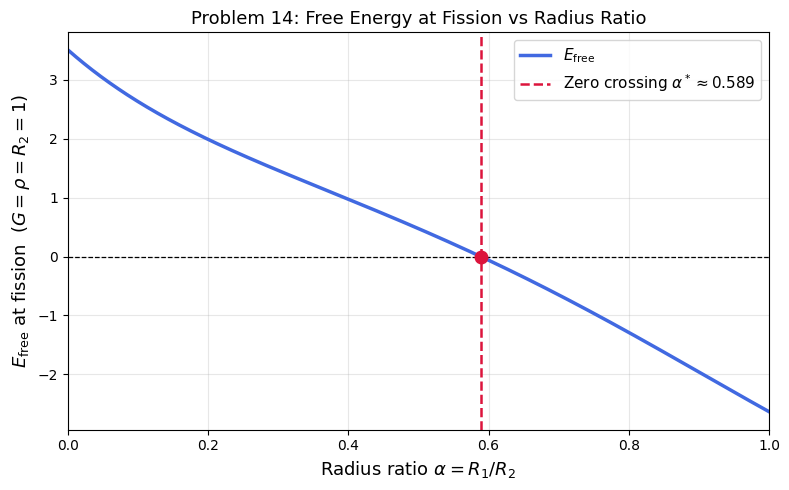

Plot saved.


In [12]:
"""
Problem 14: Full 2-Body Problem Fission Analysis
Exactly as specified in the problem instructions.

G = 1, rho = 1, R2 = 1 (normalized)
M_i = (4*pi/3) * R_i^3
"""

import numpy as np
import matplotlib.pyplot as plt

G   = 1.0
rho = 1.0
prefactor = 4.0 * np.pi / 3.0   # M_i = prefactor * R_i^3

N          = 1000
alpha_arr  = np.linspace(0.0, 1.0, N + 1)[1:]   # avoid alpha=0
E_free_arr = np.zeros(N)

for i, alpha in enumerate(alpha_arr):
    # Step 1: radii
    R1 = alpha
    R2 = 1.0

    # Step 2: masses
    M1 = prefactor * R1**3
    M2 = prefactor * R2**3

    # Step 3: separation and reduced mass
    r  = R1 + R2
    mu = M1 * M2 / (M1 + M2)

    # Step 4: total moment of inertia (spin + orbital)
    I = (2.0/5.0) * (M1 * R1**2 + M2 * R2**2) + mu * r**2

    # Step 5: fission spin rate (Keplerian)
    omega2 = G * (M1 + M2) / r**3

    # Step 6: free energy
    E_free_arr[i] = 0.5 * I * omega2 - G * M1 * M2 / r

# ── Zero crossing ─────────────────────────────────────────────────────────────
sign_changes = np.where(np.diff(np.sign(E_free_arr)))[0]
alpha_zero   = None
if len(sign_changes) > 0:
    idx        = sign_changes[0]
    alpha_zero = np.interp(0,
                           [E_free_arr[idx], E_free_arr[idx + 1]],
                           [alpha_arr[idx],  alpha_arr[idx + 1]])
    print(f"Zero crossing at alpha = R1/R2 = {alpha_zero:.4f}")
    print(f"  alpha < {alpha_zero:.4f} : E_free > 0  →  system ESCAPES")
    print(f"  alpha > {alpha_zero:.4f} : E_free < 0  →  system BOUND")

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(alpha_arr, E_free_arr, color='royalblue', linewidth=2.5,
        label=r'$E_{\rm free}$')
ax.axhline(0, color='black', linewidth=0.9, linestyle='--')

if alpha_zero is not None:
    ax.axvline(alpha_zero, color='crimson', linewidth=1.8, linestyle='--',
               label=rf'Zero crossing $\alpha^* \approx {alpha_zero:.3f}$')
    ax.plot(alpha_zero, 0, 'o', color='crimson', markersize=9, zorder=5)

    ylo, yhi = ax.get_ylim()
    """
    ax.fill_between(alpha_arr[alpha_arr < alpha_zero],
                    E_free_arr[alpha_arr < alpha_zero],
                    0, alpha=0.12, color='crimson',  label='Escapes (unbound)')
    ax.fill_between(alpha_arr[alpha_arr > alpha_zero],
                    E_free_arr[alpha_arr > alpha_zero],
                    0, alpha=0.12, color='royalblue', label='Bound orbit')
"""
ax.set_xlabel(r'Radius ratio $\alpha = R_1/R_2$', fontsize=13)
ax.set_ylabel(r'$E_{\rm free}$ at fission  $(G=\rho=R_2=1)$', fontsize=13)
ax.set_title('Problem 14: Free Energy at Fission vs Radius Ratio', fontsize=13)
ax.set_xlim([0, 1])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Plot saved.")